In [3]:
!pip install pandas matplotlib seaborn

Defaulting to user installation because normal site-packages is not writeable
   ---------------------------------------- 0.0/9.7 MB ? eta -:--:--
   - -------------------------------------- 0.3/9.7 MB ? eta -:--:--
   --- ------------------------------------ 0.8/9.7 MB 2.7 MB/s eta 0:00:04
   ------ --------------------------------- 1.6/9.7 MB 3.1 MB/s eta 0:00:03
   -------- ------------------------------- 2.1/9.7 MB 3.0 MB/s eta 0:00:03
   ------------ --------------------------- 3.1/9.7 MB 3.5 MB/s eta 0:00:02
   ---------------- ----------------------- 3.9/9.7 MB 3.6 MB/s eta 0:00:02
   -------------------- ------------------- 5.0/9.7 MB 3.9 MB/s eta 0:00:02
   ------------------------ --------------- 6.0/9.7 MB 4.0 MB/s eta 0:00:01
   --------------------------- ------------ 6.8/9.7 MB 4.1 MB/s eta 0:00:01
   ----------------------------- ---------- 7.1/9.7 MB 3.7 MB/s eta 0:00:01
   ------------------------------- -------- 7.6/9.7 MB 3.7 MB/s eta 0:00:01
   ---------------------


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: C:\Users\skate\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


# Tarea 1: Exploración de Niveles del Lenguaje


## 1. Fonética

In [1]:
import difflib

def obtener_fonologia_aproximada(palabra_buscada, lexico):
    # 1. Si la palabra existe, devuelve la transcripción normalmente
    if palabra_buscada in lexico:
        return lexico[palabra_buscada]
    
    # 2. Si no existe (OOV), buscamos la coincidencia más cercana
    similares = difflib.get_close_matches(palabra_buscada, lexico.keys(), n=1, cutoff=0.6)
    
    if similares:
        palabra_aproximada = similares[0]
        print(f"⚠️ '{palabra_buscada}' no encontrada. Aproximando a: '{palabra_aproximada}'")
        return lexico[palabra_aproximada]
    else:
        return f"❌ No se encontró '{palabra_buscada}' ni ninguna aproximación."

# --- Muestra de los 3 ejemplos solicitados ---
# (Simulamos un diccionario básico de la práctica 1)
lexico_clase = {
    "murcielago": "m u ɾ s j e l a ɣ o",
    "computadora": "k o m p u t a ð o ɾ a",
    "lenguaje": "l e ŋ ɡ w a x e"
}

# Ejemplo 1: Error de dedo tipográfico
print(obtener_fonologia_aproximada("murcielgo", lexico_clase))

# Ejemplo 2: Letra repetida
print(obtener_fonologia_aproximada("lenguajee", lexico_clase))

# Ejemplo 3: Palabra demasiado diferente (falla a propósito)
print(obtener_fonologia_aproximada("esternocleidomastoideo", lexico_clase))

⚠️ 'murcielgo' no encontrada. Aproximando a: 'murcielago'
m u ɾ s j e l a ɣ o
⚠️ 'lenguajee' no encontrada. Aproximando a: 'lenguaje'
l e ŋ ɡ w a x e
❌ No se encontró 'esternocleidomastoideo' ni ninguna aproximación.


## 2. Morfología

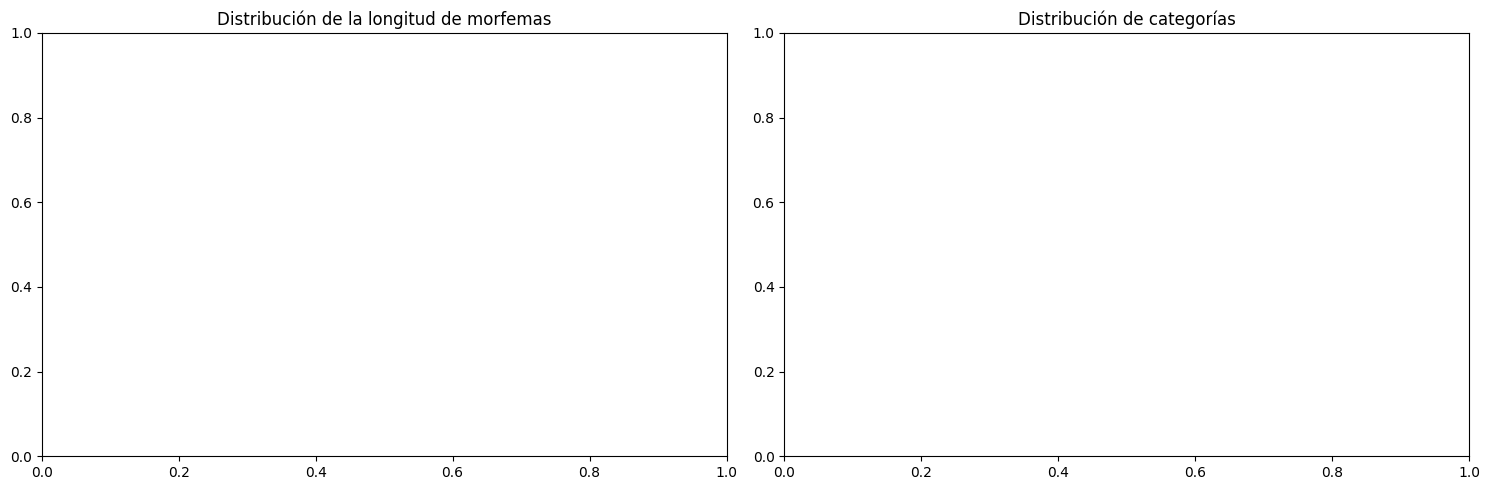

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

def analizar_lengua(df, nombre_lengua):
    # 1. Ratio Morfemas / Palabra
    morf_por_palabra = df.groupby('palabra')['morfema'].count()
    ratio = morf_por_palabra.mean()
    
    # 2. Índice de Flexión (100) / Derivación (010)
    total = len(df)
    flexion = len(df[df['etiqueta'] == '100']) / total * 100
    derivacion = len(df[df['etiqueta'] == '010']) / total * 100
    
    print(f"--- {nombre_lengua} ---")
    print(f"Ratio Morfemas/Palabra: {ratio:.2f}")
    print(f"Flexión: {flexion:.2f}% | Derivación: {derivacion:.2f}%\n")
    
    df['longitud_morfema'] = df['morfema'].astype(str).apply(len)
    return df

# APLICAR FUNCIÓN (Debes pasar tus propios DataFrames aquí)
# df_spa = analizar_lengua(df_spa, "Español (Romance)")
# df_eng = analizar_lengua(df_eng, "Inglés (Germánica)")
# df_hun = analizar_lengua(df_hun, "Húngaro (Urálica)")

# --- VISUALIZACIÓN CON SUBPLOTS ---
# Unimos los 3 dataframes para graficar (Asegúrate de haberles creado una columna 'Lengua')
# df_total = pd.concat([df_spa, df_eng, df_hun])

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Plot 1: Longitud
# sns.boxplot(data=df_total, x='Lengua', y='longitud_morfema', ax=axes[0])
axes[0].set_title('Distribución de la longitud de morfemas')

# Plot 2: Categorías
# sns.countplot(data=df_total[df_total['etiqueta'].isin(['100', '010'])], x='Lengua', hue='etiqueta', ax=axes[1])
axes[1].set_title('Distribución de categorías')

plt.tight_layout()
plt.show()

## 3. EXTRA: Etiquetador CRFs